# Calculate 2-point correlations as function of separation

We study **two-point correlation functions** of scalar fields on organoid surfaces.  
Each organoid is represented as a triangular mesh. Distances between vertices are computed using:

- **Heat method (Crane et al. 2013):** smooth geodesic approximation.  
- **Dijkstra (graph geodesic):** shortest path along mesh edges, used for comparison.  

To make correlations efficient:  
1. **Coarse-grain** vertices with farthest-point sampling.  
2. **Precompute distance bins** between vertex pairs.  
3. **Accumulate correlations per bin**, weighted by vertex areas.  

This yields normalized two-point functions of fields (e.g. HKS), revealing characteristic length scales of variation across the organoid surface.


In [5]:
from src.fatemarkers import FateMarkers

import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import glob
import os

from nonlocal_correlations import *

## Load organoid ensemble

In [6]:
data_dir = '../NicoleData/20250714/fractal_output'

# choose one timepoint/well/round
timepoint = "day4p5"
zarr_name = "r0.zarr"
well = "A06"
round_name = "0_fused_zillum"

# directory containing the organoid meshes
mesh_dir = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_annotated"

# collect all VTP files
organoid_paths = sorted(glob.glob(os.path.join(mesh_dir, "*.vtp")))

print(f"Found {len(organoid_paths)} organoids:")
for p in organoid_paths:
    print(" ", os.path.basename(p))

Found 51 organoids:
  1.vtp
  11.vtp
  14.vtp
  16.vtp
  18.vtp
  19.vtp
  2.vtp
  20.vtp
  21.vtp
  22.vtp
  23.vtp
  25.vtp
  28.vtp
  31.vtp
  32.vtp
  34.vtp
  35.vtp
  36.vtp
  37.vtp
  39.vtp
  40.vtp
  41.vtp
  42.vtp
  43.vtp
  44.vtp
  45.vtp
  46.vtp
  47.vtp
  48.vtp
  49.vtp
  50.vtp
  51.vtp
  53.vtp
  54.vtp
  55.vtp
  56.vtp
  57.vtp
  58.vtp
  59.vtp
  61.vtp
  62.vtp
  64.vtp
  65.vtp
  66.vtp
  67.vtp
  69.vtp
  70.vtp
  71.vtp
  73.vtp
  74.vtp
  75.vtp


In [7]:
def zero_low_l_modes(coeffs, l_cut):
    """
    Zero out coefficients for modes with spherical-harmonic band index ell <= l_cut.
    coeffs: (K, F)
    returns: coeffs_clean (K, F)
    """
    K, F = coeffs.shape
    coeffs_clean = coeffs.copy()
    # modes m with ell satisfying ell^2 <= m <= (ell+1)^2 - 1 for ell = 0..l_cut inclusive
    max_m = min(K, (l_cut+1)**2)  # upper bound (exclusive)
    if max_m <= 0:
        return coeffs_clean
    coeffs_clean[:max_m, :] = 0.0
    return coeffs_clean


def connected_and_normalized_correlations(Corr: np.ndarray, N: np.ndarray, X: np.ndarray):
    """
    Compute connected and normalized correlation functions.

    Args
    ----
    Corr : ndarray, shape (B, F, F)
        Raw correlation matrices per distance bin (output of accumulate_correlations_from_bins).
    N : ndarray, shape (B,)
        Normalization weights per distance bin (from accumulate_correlations_from_bins).
    X : ndarray, shape (V, F)
        Field values on vertices/cell centers (used to compute means and stds).

    Returns
    -------
    Corr_conn : ndarray, shape (B, F, F)
        Connected correlations: <F_i F_j> - <F_i><F_j>.
    Corr_norm : ndarray, shape (B, F, F)
        Connected + normalized correlations:
            ( <F_i F_j> - <F_i><F_j> ) / (\sigma_i \sigma_j).
    """
    F = Corr.shape[1]

    # --- global statistics for normalization ---
    means = np.mean(X, axis=0)       # (F,)
    vars_ = np.var(X, axis=0)        # (F,)
    stds = np.sqrt(vars_ + 1e-12)    # avoid div-by-zero

    # --- connected correlations ---
    Corr_conn = np.copy(Corr)
    for b in range(Corr.shape[0]):
        if N[b] > 0:
            Corr_conn[b] -= np.outer(means, means)
        else:
            Corr_conn[b] = np.full((F, F), np.nan)

    # --- normalized connected correlations ---
    Corr_norm = np.copy(Corr_conn)
    for b in range(Corr.shape[0]):
        if N[b] > 0:
            Corr_norm[b] /= np.outer(stds, stds)
        else:
            Corr_norm[b] = np.full((F, F), np.nan)

    return Corr_conn, Corr_norm

In [8]:
Corr_all = []
Corr_conn_all = []
Corr_norm_all = []

bins_dist_all = []
pair_counts_all = []
tot_area_all = []
tot_volume_all = []
num_cell_all = []

dmax = 20
nbins = 64
bin_edges = np.linspace(0.0, dmax, nbins + 1)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])


for path in organoid_paths:
    print(f"Processing {path}")

    # Process mesh
    m = FateMarkers()
    m.load_mesh_from_file(path)
    m.align_with_pca()
    _, coeffs_fields = m.compute_coefficients(lmax=15)
    L, M = build_cotangent_laplacian_and_mass(m.v, m.f)

    _, patch_centers = get_patch_centers(m.v, m.fields[:,0])
    vertex_areas = np.array(M.diagonal())

    volume = mesh_volume_from_triangles(m.v, m.f)

    # Process fields
    hks = m.compute_hks_for_new_times(new_ts=[4.0], coeffs=False)
    coeffs_hks = m.compute_hks_for_new_times(new_ts=[4.0], coeffs=True)

    vertex_fields = np.concatenate([hks, m.fields[:,3::2]], axis=1)
    _, cell_areas, cell_weighted_fields, _, _ = per_cell_stats_from_vertex_labels(m.v, m.f, vertex_areas, m.fields[:,0], vertex_fields)
    vertex_fields = vertex_fields[patch_centers, :]

    # Process geodesics
    dist_heat = heat_geodesic_all_sources(m.v, m.f, L, M, t=None, sources=patch_centers)  # (S,V)
    dist_heat = dist_heat[:, patch_centers] # (S,S)

    bins_dist = pair_bins_from_distances(dist_heat, cell_areas, bin_edges, use_area_weights=False)
    counts_bin = np.array([len(bins_dist[f'I_{b}']) for b in range(len(bin_edges)-1)])

    # Compute correlations
    Corr, N = accumulate_correlations_from_bins(bins_dist, vertex_fields) # compute surface area weighted correlations
    Corr_conn, Corr_norm = connected_and_normalized_correlations(Corr, N, vertex_fields)


    # store everything
    Corr_all.append(Corr)
    Corr_conn_all.append(Corr_conn)
    Corr_norm_all.append(Corr_norm)
    bins_dist_all.append(bins_dist)
    pair_counts_all.append(counts_bin)
    tot_area_all.append( np.sum(vertex_areas) )
    tot_volume_all.append( volume )
    num_cell_all.append( cell_areas.shape[0])  
    

Processing ../NicoleData/20250714/fractal_output/day4p5/r0.zarr/A/06/0_fused_zillum/meshes/nnorg_linked_annotated/1.vtp


heat sources: 100%|██████████| 338/338 [00:01<00:00, 217.57it/s]


Processing ../NicoleData/20250714/fractal_output/day4p5/r0.zarr/A/06/0_fused_zillum/meshes/nnorg_linked_annotated/11.vtp


heat sources: 100%|██████████| 255/255 [00:01<00:00, 223.04it/s]


Processing ../NicoleData/20250714/fractal_output/day4p5/r0.zarr/A/06/0_fused_zillum/meshes/nnorg_linked_annotated/14.vtp


...

heat sources: 100%|██████████| 500/500 [00:02<00:00, 222.85it/s]


Processing ../NicoleData/20250714/fractal_output/day4p5/r0.zarr/A/06/0_fused_zillum/meshes/nnorg_linked_annotated/74.vtp


heat sources: 100%|██████████| 22/22 [00:00<00:00, 227.18it/s]


Processing ../NicoleData/20250714/fractal_output/day4p5/r0.zarr/A/06/0_fused_zillum/meshes/nnorg_linked_annotated/75.vtp


heat sources: 100%|██████████| 686/686 [00:02<00:00, 231.96it/s]


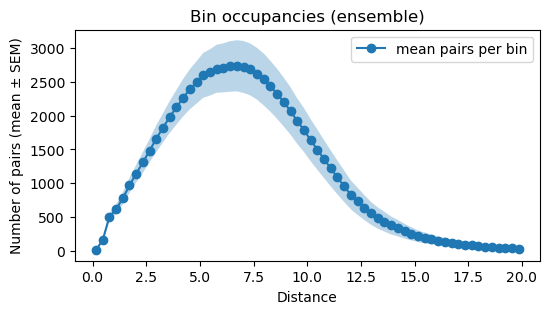

In [9]:
pair_counts_arr = np.stack(pair_counts_all, axis=0)  # (n_org, B)
mean_counts = pair_counts_arr.mean(axis=0)
std_counts = pair_counts_arr.std(axis=0, ddof=1)
sem_counts = std_counts / np.sqrt(pair_counts_arr.shape[0])

plt.figure(figsize=(6,3))
plt.plot(bin_centers, mean_counts, 'o-', label='mean pairs per bin')
plt.fill_between(bin_centers, mean_counts - sem_counts, mean_counts + sem_counts, alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("Number of pairs (mean ± SEM)")
plt.title("Bin occupancies (ensemble)")
plt.legend()
plt.show()


In [10]:
# convert lists -> arrays with shape (n_org, B, F, F)
Corr_all = np.stack(Corr_all, axis=0)    # (n_org, B, F, F)
Corr_conn_all = np.stack(Corr_conn_all, axis=0)    # (n_org, B, F, F)
Corr_norm_all = np.stack(Corr_norm_all, axis=0)    # (n_org, B, F, F)


# number of organoids
n_org = Corr_all.shape[0]


In [ ]:
import scikits.bootstrap as boot

# Each array has shape (n_org, B, F, F)
corr_dict = {
    "C": np.stack(Corr_all, axis=0),
    "C_conn": np.stack(Corr_conn_all, axis=0),
    "C_norm": np.stack(Corr_norm_all, axis=0),
}

# Pick which field indices you want to analyze, e.g. autocorr of field 0
i, j = 0, 0   # change as needed

# Store results
ci_results = {}

for name, arr in corr_dict.items():
    # extract data across organoids for this (i,j) field pair
    # shape: (n_org, B) → transpose to (B, n_org)
    data = arr[:, :, i, j].T

    ci_low = []
    ci_high = []
    for b in range(data.shape[0]):
        ci = boot.ci(
            data[b], 
            statfunction=np.nanmean, 
            method='bca', 
            alpha=0.05, 
            n_samples=2000
        )
        ci_low.append(ci[0])
        ci_high.append(ci[1])

    ci_results[name] = {
        "low": np.array(ci_low),
        "high": np.array(ci_high)
    }

/tmp/ipykernel_31436/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_31436/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_31436/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_31436/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_31436/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_31436/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_31436/3870216316.py:24: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/i

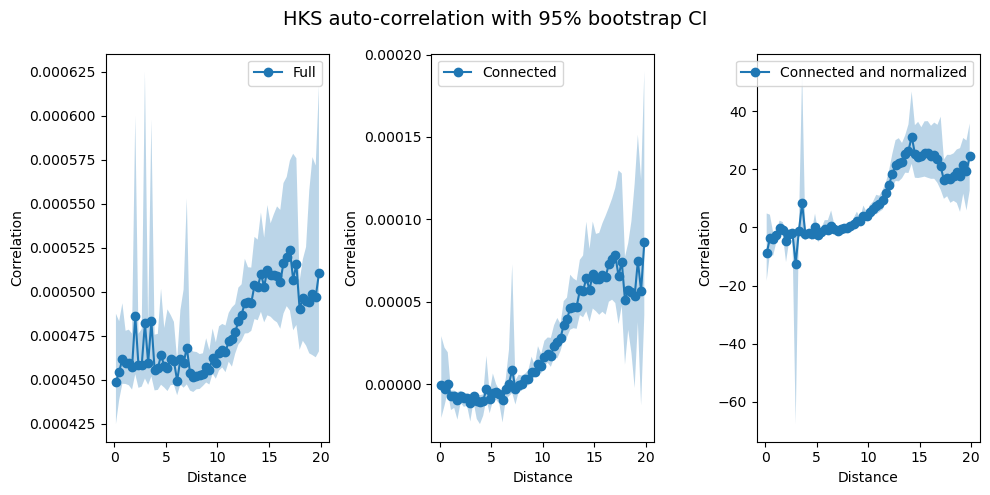

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
mean_C = np.nanmean(corr_dict["C"], axis=0)  # (B,F,F)
plt.plot(bin_centers, mean_C[:,0,0], 'o-', label="Full")
plt.fill_between(
    bin_centers,
    ci_results["C"]["low"],
    ci_results["C"]["high"],
    alpha=0.3
)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.legend()


plt.subplot(1,3,2)
mean_C = np.nanmean(corr_dict["C_conn"], axis=0)  # (B,F,F)
plt.plot(bin_centers, mean_C[:,0,0], 'o-', label="Connected")
plt.fill_between(
    bin_centers,
    ci_results["C_conn"]["low"],
    ci_results["C_conn"]["high"],
    alpha=0.3
)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.legend()


plt.subplot(1,3,3)
mean_C = np.nanmean(corr_dict["C_norm"], axis=0)  # (B,F,F)
plt.plot(bin_centers, mean_C[:,0,0], 'o-', label="Connected and normalized")
plt.fill_between(
    bin_centers,
    ci_results["C_norm"]["low"],
    ci_results["C_norm"]["high"],
    alpha=0.3
)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.legend()

plt.suptitle("HKS auto-correlation with 95% bootstrap CI", fontsize=14)

plt.tight_layout()
plt.show()


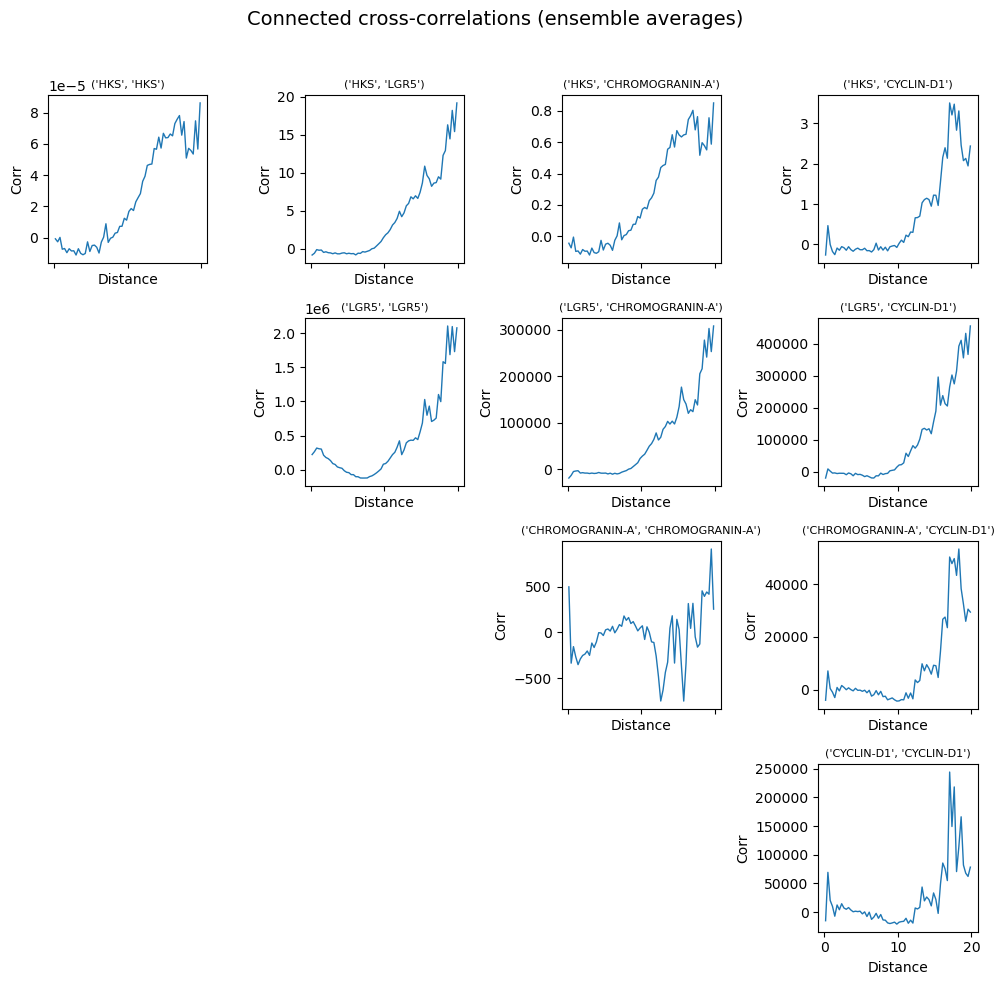

In [ ]:
n_org, B, F, _ = Corr_all.shape
field_names = ["HKS", "LGR5", "CHROMOGRANIN-A", "CYCLIN-D1"]

fig, axes = plt.subplots(F, F, figsize=(10, 10), sharex=True, sharey=False)

for i in range(F):
    for j in range(F):
        ax = axes[i, j]

        if i > j:
            ax.axis("off")  # hide lower triangle
            continue

        # Plot the four variants
        ax.plot(bin_centers, np.nanmean(Corr_conn_all[:,:,i,j], axis=0),  '-',  lw=1,
                label="Connected" if (i==0 and j==0) else "")
        
        ax.set_title((field_names[i], field_names[j]), fontsize=8)
        ax.set_ylabel("Corr", fontsize=10)
        ax.set_xlabel("Distance", fontsize=10)

# Global labels + legend
fig.suptitle("Connected cross-correlations (ensemble averages)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Group organoids

If the organoids do not develop any protrusions, i.e. they are sphere-like, they will likely show different correlation behavior. Hence it may be worth exploring whether we need to calculate correlations across groups, rather than days. 

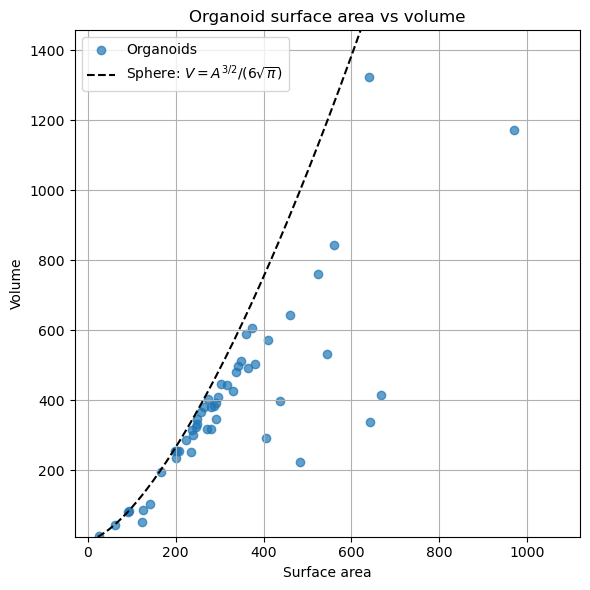

In [ ]:
tot_area_all = np.stack(tot_area_all, axis=0)
tot_volume_all = np.stack(tot_volume_all, axis=0)

plt.figure(figsize=(6,6))
plt.scatter(tot_area_all, tot_volume_all, alpha=0.7, label="Organoids")

# Reference curve: sphere relation
A_range = np.linspace(tot_area_all.min()*0.9, tot_area_all.max()*1.1, 200)
V_sphere = (1.0 / (6.0 * np.sqrt(np.pi))) * (A_range**1.5)

plt.plot(A_range, V_sphere, 'k--', label=r"Sphere: $V = A^{3/2} / (6\sqrt{\pi})$")

plt.xlabel("Surface area")
plt.ylabel("Volume")
plt.title("Organoid surface area vs volume")
plt.legend()
plt.grid(True)

plt.ylim(tot_volume_all.min()*0.9, tot_volume_all.max()*1.1)
plt.tight_layout()

plt.show()



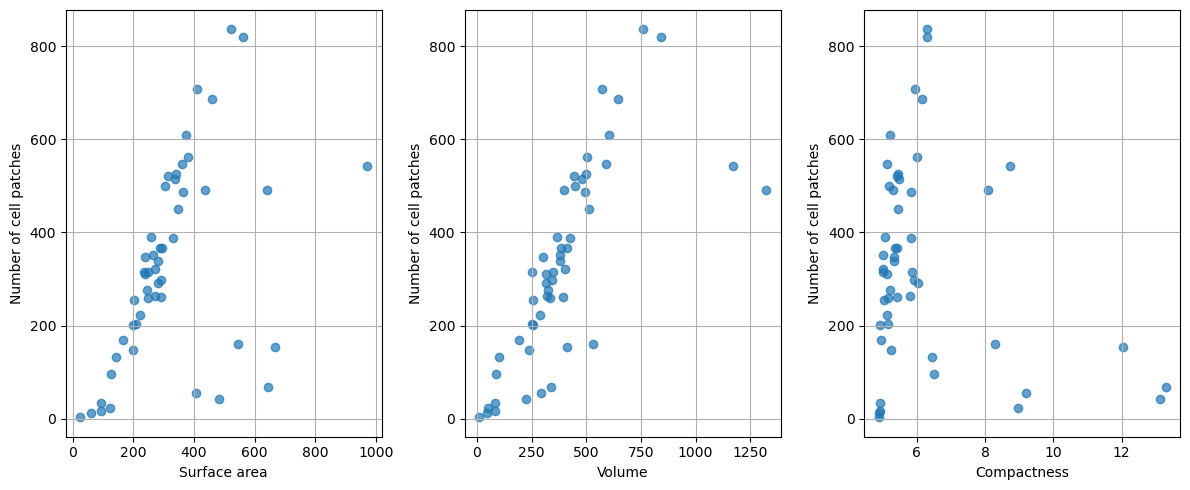

In [ ]:
num_cells = np.stack(num_cell_all, axis=0)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.scatter(tot_area_all, num_cells, alpha=0.7)
plt.xlabel("Surface area")
plt.ylabel("Number of cell patches")
plt.grid(True)

plt.subplot(1,3,2)
plt.scatter(tot_volume_all, num_cells, alpha=0.7)
plt.xlabel("Volume")
plt.ylabel("Number of cell patches")
plt.grid(True)


plt.subplot(1,3,3)
plt.scatter(tot_area_all / (tot_volume_all ** (2.0/3.0)), num_cells, alpha=0.7)
plt.xlabel("Compactness")
plt.ylabel("Number of cell patches")
plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
compactness = tot_area_all / (tot_volume_all ** (2.0/3.0))

comp_sphere = 4.835
threshold = 1.20 * comp_sphere   # 20% larger than sphere
group_sphere_like = (compactness <= threshold) & (tot_volume_all >= 200)
group_protruded   = (compactness > threshold) & (tot_volume_all >= 200)

print(np.sum(group_sphere_like))
print(np.sum(group_protruded))

26
17


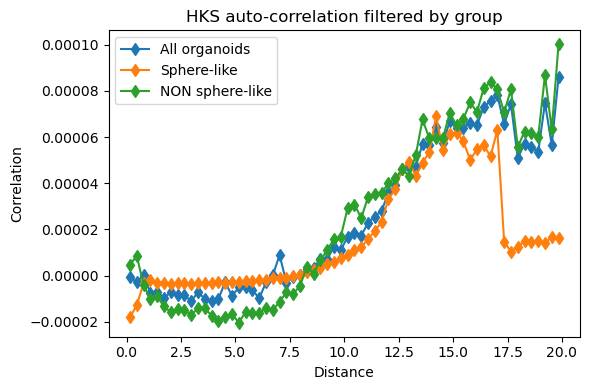

In [ ]:
Corr_sphere = np.nanmean(Corr_conn_all[group_sphere_like], axis=0)    # (B,F,F)
Corr_protruded = np.nanmean(Corr_conn_all[group_protruded], axis=0)    # (B,F,F)

plt.figure(figsize=(6,4))
# Equal, raw field
plt.plot(bin_centers, np.nanmean(Corr_conn_all[:,:,0,0], axis=0), 'd-', label="All organoids")
plt.plot(bin_centers, Corr_sphere[:,0,0], 'd-', label="Sphere-like")
plt.plot(bin_centers, Corr_protruded[:,0,0], 'd-', label="NON sphere-like")

plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("HKS auto-correlation filtered by group")
plt.legend()
plt.tight_layout()
plt.show()

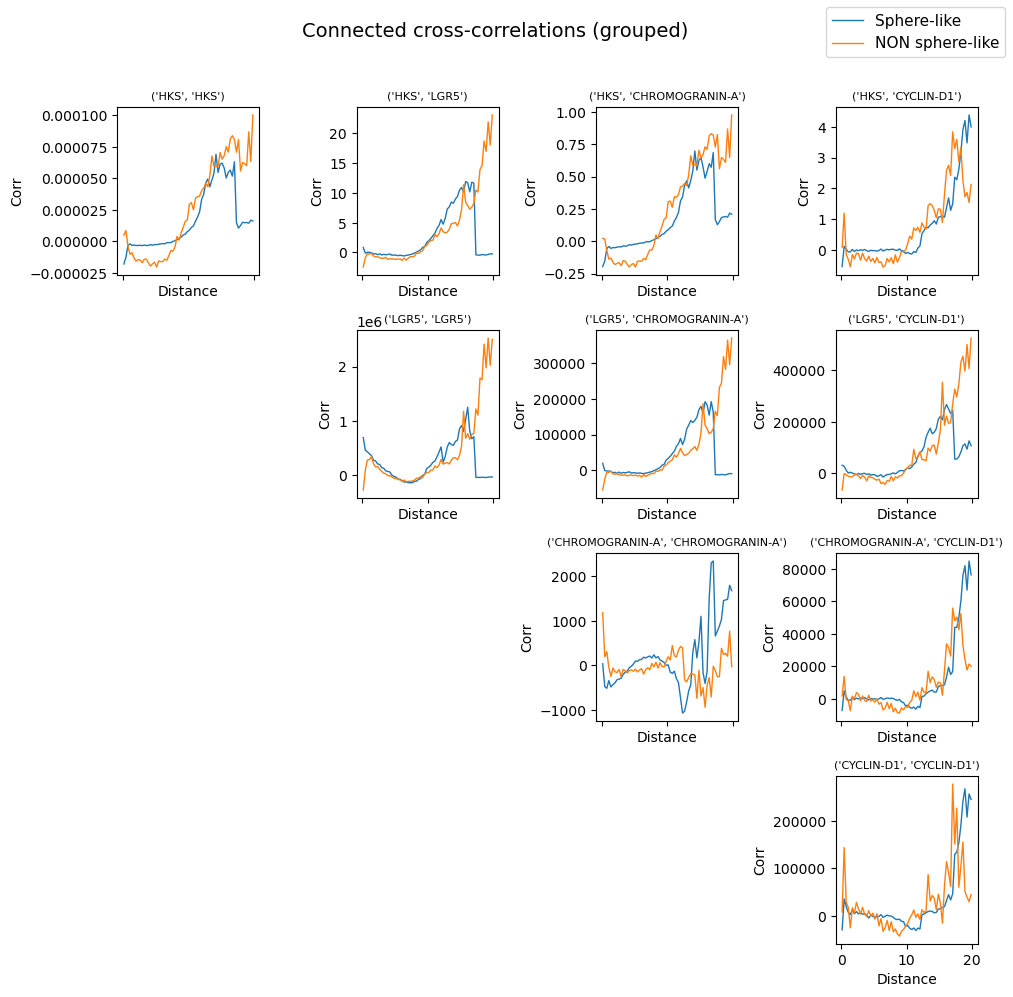

In [ ]:
n_org, B, F, _ = Corr_all.shape
field_names = ["HKS", "LGR5", "CHROMOGRANIN-A", "CYCLIN-D1"]

fig, axes = plt.subplots(F, F, figsize=(10, 10), sharex=True, sharey=False)

for i in range(F):
    for j in range(F):
        ax = axes[i, j]

        if i > j:
            ax.axis("off")  # hide lower triangle
            continue

        # # Plot the four variants
        # ax.plot(bin_centers, np.nanmean(Corr_conn_all[:,:,i,j], axis=0),  '-',  lw=1,
        #         label="All organoids" if (i==0 and j==0) else "")
        
        ax.plot(bin_centers, Corr_sphere[:,i,j],  '-',  lw=1,
                label="Sphere-like" if (i==0 and j==0) else "")
        
        ax.plot(bin_centers, Corr_protruded[:,i,j],  '-',  lw=1,
                label="NON sphere-like" if (i==0 and j==0) else "")
        
        
        ax.set_title((field_names[i], field_names[j]), fontsize=8)
        ax.set_ylabel("Corr", fontsize=10)
        ax.set_xlabel("Distance", fontsize=10)

# Global labels + legend
fig.suptitle("Connected cross-correlations (grouped)", fontsize=14)
fig.legend(loc="upper right", fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


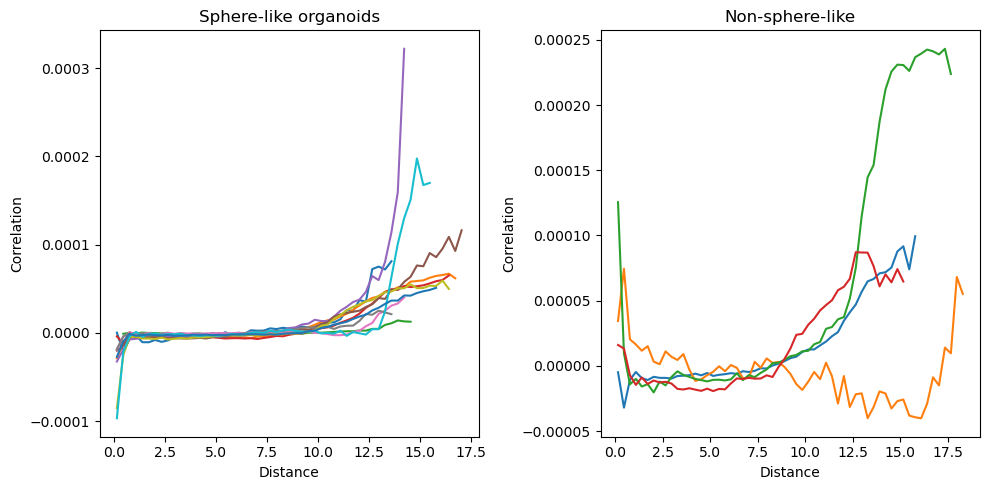

In [ ]:
# Get orgnaoids with similar colume from the two groups
vol_min = 350
vol_max = 500

group_sph_vol = (compactness <= threshold) & (tot_volume_all >= vol_min) & (tot_volume_all <= vol_max)
group_pro_vol   = (compactness > threshold) & (tot_volume_all >= vol_min) & (tot_volume_all <= vol_max)


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(bin_centers, Corr_conn_all[group_sph_vol,:,0,0].T)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Sphere-like organoids")


plt.subplot(1,2,2)
plt.plot(bin_centers, Corr_conn_all[group_pro_vol,:,0,0].T)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Non-sphere-like")

plt.tight_layout()
plt.show()


In [ ]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.manifold import MDS
from sklearn.cluster import KMeans


def cluster_correlations(C_all, threshold = 0.8, k=2):

    # C_all: (n_org, B) correlation curves (NaNs at long distances)
    n_org, B = C_all.shape

    # 1) compute coverage per bin
    valid_counts = np.sum(~np.isnan(C_all), axis=0)   # shape (B,)
    frac = valid_counts / n_org

    # 2) choose bins where fraction >= threshold
    mask_bins = frac >= threshold
    print("Using", mask_bins.sum(), "bins out of", B)

    # 3) build feature matrix truncated
    X = C_all[:, mask_bins]

    # 4) for each organoid, if there are still NaNs inside truncated region (rare), impute with linear interp or fill with bin mean
    for i in range(n_org):
        row = X[i]
        if np.isnan(row).any():
            # linear interp across available points
            good = ~np.isnan(row)
            if good.sum() >= 2:
                xp = np.where(good)[0]
                fp = row[good]
                x = np.arange(len(row))
                X[i] = np.interp(x, xp, fp)
            else:
                # fallback: fill with zeros
                X[i] = np.nan_to_num(row, nan=0.0)

    # 5) standardize per-sample (z-score) or globally. Here per-sample:
    # Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, ddof=1, keepdims=True) + 1e-12)
    Xz = (X ) / (X.std(axis=1, ddof=1, keepdims=True) + 1e-12)
    # Xz = (X ) / (X.mean(axis=1, keepdims=True) + 1e-12)
    # Xz = X

    # 6) cluster
    km = KMeans(n_clusters=k, random_state=0).fit(Xz)
    labels = km.labels_

    return km, labels, mask_bins, Xz

Using 42 bins out of 64
34
11


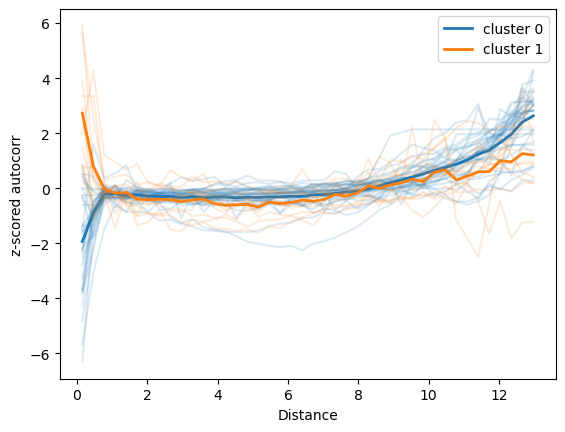

In [ ]:
vol_min = 100
C_cluster = Corr_conn_all[tot_volume_all>vol_min,:,0,0]

km, labels, mask_bins, Cz = cluster_correlations(C_cluster, k=2, threshold=0.8)


centroids = km.cluster_centers_
r_plot = bin_centers[mask_bins]
plt.figure()
for c in range(km.n_clusters):
    members = Cz[labels==c]

    print(members.shape[0])

    # plot member curves lightly
    for row in members:
        plt.plot(r_plot, row, color=f"C{c}", alpha=0.15)
    # plot centroid
    plt.plot(r_plot, centroids[c], color=f"C{c}", lw=2, label=f"cluster {c}")
plt.legend()
plt.xlabel("Distance")
plt.ylabel("z-scored autocorr")
plt.show()

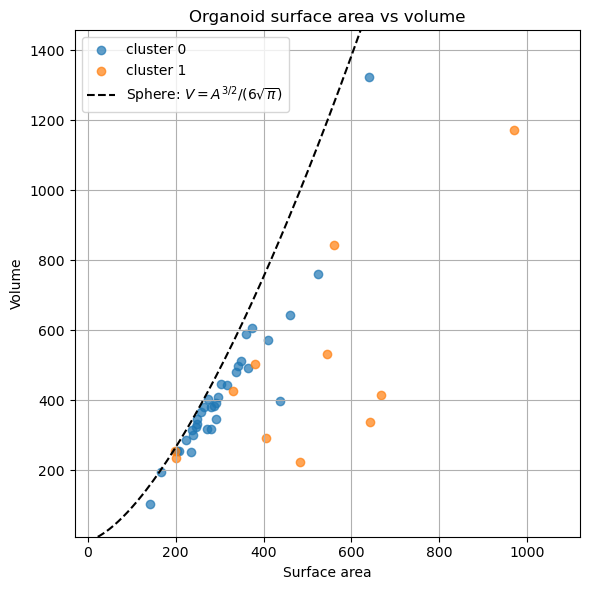

In [ ]:
tot_area_tmp = tot_area_all[tot_volume_all>vol_min]
tot_volume_tmp = tot_volume_all[tot_volume_all>vol_min]

plt.figure(figsize=(6,6))
for c in range(km.n_clusters):
    plt.scatter(tot_area_tmp[labels==c], tot_volume_tmp[labels==c], color=f"C{c}", alpha=0.7, label=f"cluster {c}")

# Reference curve: sphere relation
A_range = np.linspace(tot_area_all.min()*0.9, tot_area_all.max()*1.1, 200)
V_sphere = (1.0 / (6.0 * np.sqrt(np.pi))) * (A_range**1.5)

plt.plot(A_range, V_sphere, 'k--', label=r"Sphere: $V = A^{3/2} / (6\sqrt{\pi})$")

plt.xlabel("Surface area")
plt.ylabel("Volume")
plt.title("Organoid surface area vs volume")
plt.legend()
plt.grid(True)

plt.ylim(tot_volume_all.min()*0.9, tot_volume_all.max()*1.1)
plt.tight_layout()

plt.show()

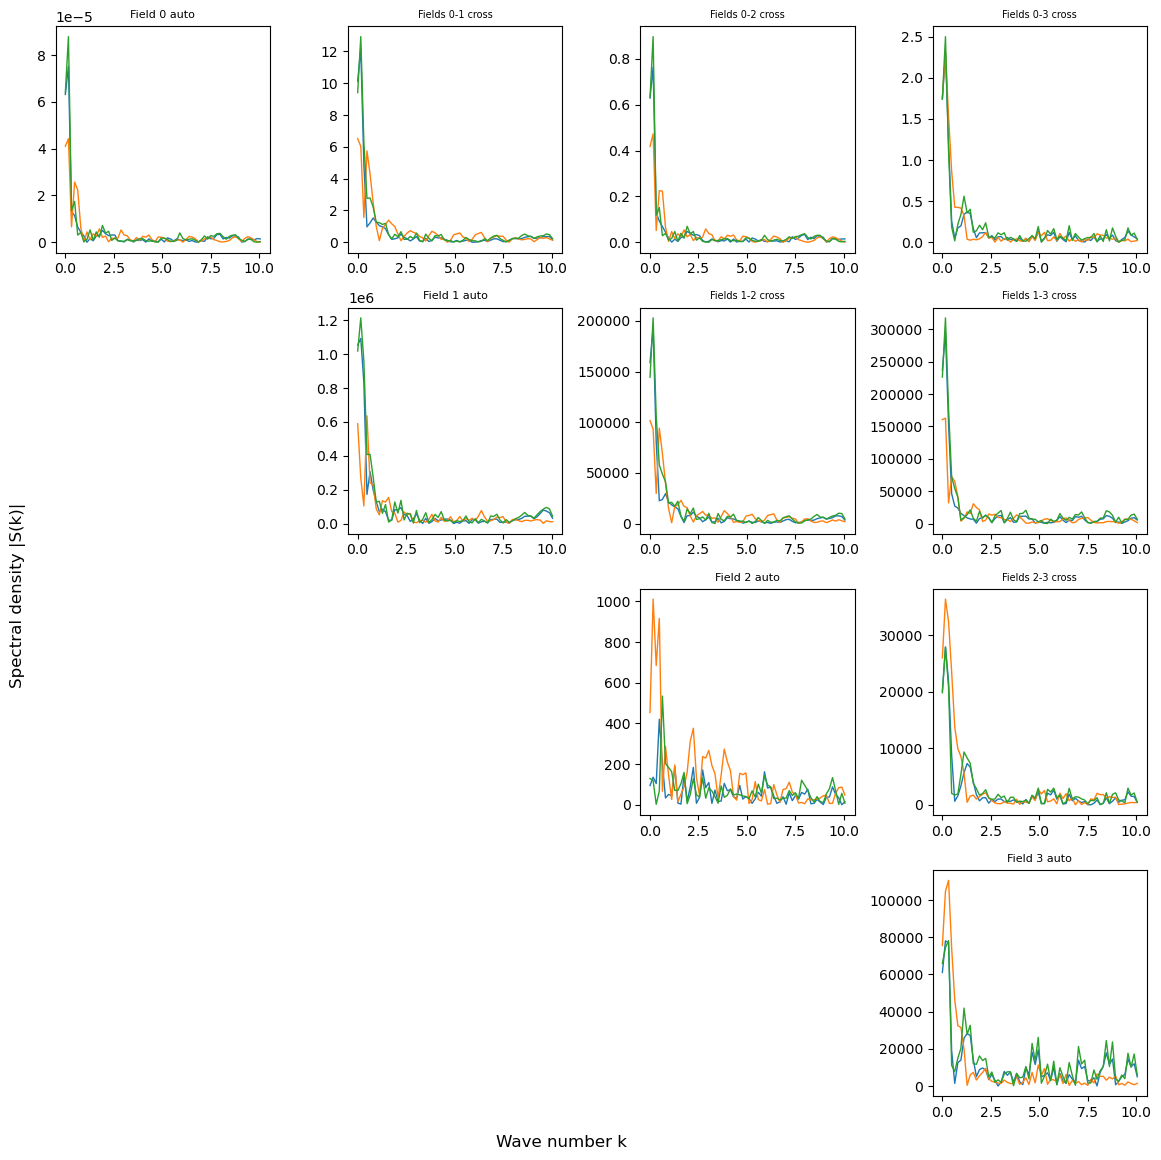

In [ ]:
from scipy.fft import dct

# --- Input ---
r = bin_centers
dr = r[1] - r[0]

# --- Compute power spectra for all fields ---
# Apply DCT along the bin axis (axis=0)
S_all = dct(np.nanmean(Corr_conn_all, axis=0), type=2, axis=0, norm='ortho') * dr   # shape (B, F, F)
S_sph = dct(Corr_sphere, type=2, axis=0, norm='ortho') * dr   # shape (B, F, F)
S_pro = dct(Corr_protruded, type=2, axis=0, norm='ortho') * dr   # shape (B, F, F)


# Define corresponding wave numbers
k = np.pi * np.arange(B) / (r[-1] - r[0])

# --- Plotting ---
fig, axes = plt.subplots(F, F, figsize=(12, 12))

for i in range(F):
    for j in range(F):
        ax = axes[i, j]

        if i > j:
            ax.axis('off')  # only plot upper triangle to avoid duplicates
            continue

        ax.plot(k, np.abs(S_all[:, i, j]), '-', lw=1, label='all organoids')
        ax.plot(k, np.abs(S_sph[:, i, j]), '-', lw=1, label='sphere-like')
        ax.plot(k, np.abs(S_pro[:, i, j]), '-', lw=1, label='non sphere-like')

        # Label diagonals with field names
        if i == j:
            ax.set_title(f"Field {i} auto", fontsize=8)
        else:
            ax.set_title(f"Fields {i}-{j} cross", fontsize=7)

# Add common labels
fig.text(0.5, 0.04, 'Wave number k', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Spectral density |S(k)|', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()
